In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
env = gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=False, render_mode="ansi")

def random_walk(episodes=100):
    successes = 0
    for _ in range(episodes):
        state, info = env.reset()
        done = False
        while not done:
            action = env.action_space.sample() # Losowy ruch
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            if reward == 1:
                successes += 1
    return successes

print(f"Sukcesy agenta losowego na 100 prób: {random_walk()}")

Sukcesy agenta losowego na 100 prób: 3


In [5]:
q_table = np.zeros((env.observation_space.n, env.action_space.n))

learning_rate = 0.1    # Jak szybko agent nadpisuje starą wiedzę
gamma = 0.95           # Współczynnik dyskontowania (znaczenie przyszłych nagród)
epsilon = 1.0          # Początkowa szansa na ruch losowy (eksploracja)
epsilon_decay = 0.001  # Jak szybko zmniejszamy eksplorację
min_epsilon = 0.01
episodes = 2000

In [6]:
outcomes = [] # Lista do przechowywania wyników (0 lub 1)

for i in range(episodes):
    state, info = env.reset()
    done = False
    
    while not done:
        # Wybór akcji: losowy lub z tabeli Q (Epsilon-Greedy)
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        # Wykonanie akcji
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Aktualizacja Tabeli Q (Równanie Bellmana)
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state])
        
        # Nowa wartość Q
        q_table[state, action] = old_value + learning_rate * (reward + gamma * next_max - old_value)
        
        state = next_state
        
    # Zmniejszanie epsilon po każdym epizodzie
    epsilon = max(min_epsilon, epsilon - epsilon_decay)
    outcomes.append(reward)

print("Uczenie zakończone!")

Uczenie zakończone!


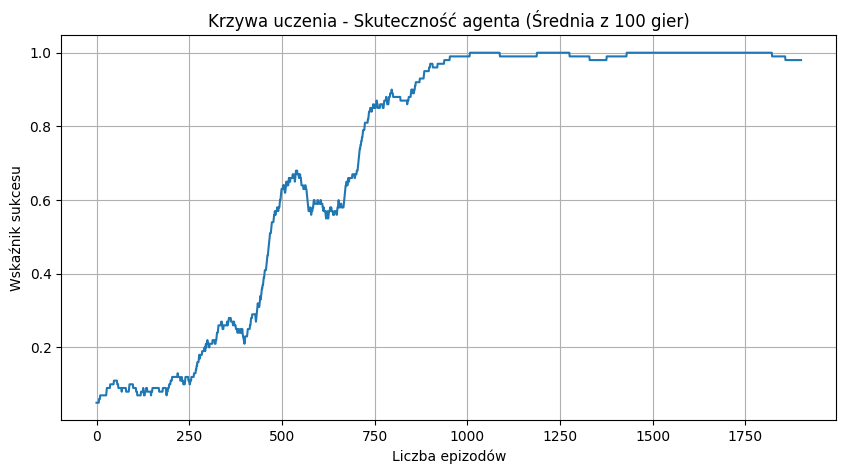

In [7]:
# Obliczanie średniej kroczącej ze 100 epizodów
def moving_average(a, n=100):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[: -n]
    return ret[n - 1 :] / n

plt.figure(figsize=(10, 5))
plt.plot(moving_average(outcomes))
plt.title("Krzywa uczenia - Skuteczność agenta (Średnia z 100 gier)")
plt.xlabel("Liczba epizodów")
plt.ylabel("Wskaźnik sukcesu")
plt.grid(True)
plt.show()

In [10]:
print("Finalna Tabela Q (Wartości dla każdego pola):")
print(q_table)

# Test - jedna gra z wizualizacją
state, info = env.reset()
env_human = gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=False, render_mode="human")
state, info = env_human.reset()
done = False

print("\nUruchamiam pokazową grę (sprawdź nowe okno)...")
# (Uwaga: to zadziała tylko na komputerze lokalnym, nie w Google Colab bez dodatków)
for _ in range(20):
    action = np.argmax(q_table[state])
    state, reward, terminated, truncated, _ = env_human.step(action)
    if terminated or truncated: break
env_human.close()

Finalna Tabela Q (Wartości dla każdego pola):
[[0.73419433 0.68691943 0.77378094 0.73497854]
 [0.73459668 0.         0.81450625 0.7734778 ]
 [0.77320853 0.857375   0.76837634 0.81233978]
 [0.81356894 0.         0.51978332 0.63358448]
 [0.44309665 0.28471268 0.         0.73184353]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.         0.81259993]
 [0.         0.         0.         0.        ]
 [0.18661182 0.         0.61532086 0.10609142]
 [0.23545859 0.57851544 0.89578284 0.        ]
 [0.82574271 0.95       0.         0.85270715]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.23564402 0.94209002 0.31347871]
 [0.8488478  0.94081505 1.         0.8850436 ]
 [0.         0.         0.         0.        ]]

Uruchamiam pokazową grę (sprawdź nowe okno)...


## Wersja z artykułu

In [21]:
import gymnasium as gym
import numpy as np
from tqdm import tqdm
import random
import pickle
import matplotlib.pyplot as plt
from gymnasium.envs.toy_text.frozen_lake import generate_random_map
import pickle

#### Appendix

In [18]:
from dataclasses import dataclass
from datargs import parse

@dataclass
class ExperimentSetup:
    name: str
    lr: float = 0.9
    gamma: float = 0.95
    epsilon: float = 1.0
    min_epsilon: float = 0.005
    max_epsilon: float = 1
    epsilon_decay: float = 0.05
    max_steps: int = 500
    total_episodes: int = 500
    map_size: int = 4
    min_lr: float = 0.3
    max_lr: float = 0.9
    lr_decay: float = 0.0001
    modify_lr: bool = False
    modify_epsilon: bool = False
    repetitions: int = 50
    results_folder: str = "results"
    holes_no: Optional[int] = None

    @staticmethod
    def get():
        return parse(ExperimentSetup)

# then, before training:
args = ExperimentSetup.get()

NameError: name 'Optional' is not defined

In [19]:
@dataclass
class Result:
    steps_per_epoch: List[List[int]]
    reward_per_episode: List[List[float]]
    holes_numbers: List[int]
    settings: ExperimentSetup

NameError: name 'List' is not defined

In [20]:
def execute_episodes(env: gym.Env, q_table: np.ndarray, args: ExperimentSetup) -> Tuple[List[float], List[int]]:
    total_episodes = args.total_episodes
    learning_rate = args.lr
    gamma = args.gamma
    epsilon = args.epsilon
    steps_per_episode = []
    success = []
    env.reset()
    for episode in range(total_episodes):
        state = env.reset()
        step = 0
        done = False
        episode_reward = 0
        while not done:
            step += 1
            try:
                state = state[0]
            except:
                pass
            random_number = random.uniform(0, 1)
            if random_number > epsilon and np.max(q_table[state]) > 0:
                action = np.argmax(q_table[state])
            else:
                action = env.action_space.sample()

            new_state, reward, done, _, _ = env.step(action)
            q_table[state, action] = q_table[state, action] + learning_rate * (
                reward + gamma * np.max(q_table[new_state, :]) - q_table[state, action]
            )
            state = new_state
            episode_reward += reward
            if step >= args.max_steps:
                break

        if args.modify_lr:
            min_lr = args.min_lr
            max_lr = args.max_lr
            lr_decay = args.lr_decay
            learning_rate = min_lr + (max_lr - min_lr) * np.exp(-lr_decay * episode)

        if args.modify_epsilon:
            min_epsilon = args.min_epsilon
            max_epsilon = args.max_epsilon
            decay_rate = args.epsilon_decay
            epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
        steps_per_episode.append(step)
        success.append(episode_reward)
    return success, steps_per_episode

NameError: name 'ExperimentSetup' is not defined

In [ ]:
map_name = "FrozenLake-v1"
def train(args: ExperimentSetup):
    results = []
    epoch_success_rate = []
    epoch_steps = []
    for rep in tqdm(range(args.repetitions)):
        env = gym.make(
            map_name,
            is_slippery=False,
            desc=generate_random_map(size=args.map_size),
        )
        state_size = env.observation_space.n
        action_size = env.action_space.n
        q_table = np.zeros((state_size, action_size))
        success_rate, steps = execute_episodes(env, q_table, args)
        epoch_success_rate.append(success_rate)
        epoch_steps.append(steps)
    return epoch_success_rate, epoch_steps

In [ ]:
@dataclass
class Result:
    steps_per_epoch: List[List[int]]
    rolling_success: List[List[float]]
    settings: ExperimentSetup

def get_file_location(settings: ExperimentSetup):
    return f"./{settings.results_folder}/{settings.name}"

def save(data: Result):
    out = get_file_location(data.settings)
    pickle.dump(data, open(out, "wb"))

def read(folder: str, file_name: str):
    return pickle.load(open(f"./{folder}/{file_name}", "rb"))

def run():
    args = ExperimentSetup.get()
    return run_with_arguments(args)

def run_with_arguments(args: ExperimentSetup) -> Result:
    success_rate, steps, holes_numbers = train(args)
    data = Result(steps, success_rate, holes_numbers, args)
    save(data)
    return data

In [ ]:
data = read("results", "baseline")
reward_per_episode = data.reward_per_episode
cumulative_reward_per_episode = np.cumsum(reward_per_episode, axis=1)
reward_df = pd.DataFrame(cumulative_reward_per_episode).transpose()

fig, ax = plt.subplots(figsize=(15, 5))
sns.lineplot(reward_df, legend=False, ax=ax)
plt.show()
ax.get_xaxis().set_label_text('Episode')
ax.get_yaxis().set_label_text('Cumulative score')

In [ ]:
df = pd.DataFrame(reward_per_episode)
df = df[df.nunique(axis=1) > 1]
success_df = df.transpose().cumsum()
fig, ax = plt.subplots(figsize=(15, 5))
sns.lineplot(success_df, legend=False, ax=ax)
ax.get_xaxis().set_label_text('Episode')
ax.get_yaxis().set_label_text('Cumulative score')
plt.savefig('baseline-score.png')
plt.show()


last_row = success_df.iloc[-1]
print(last_row.min()) # 1.0
print(last_row.mean()) # 92.2258064516129
print(last_row.max()) # 439.0
print(last_row.median()) # 39.0

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
df1 = success_df.divide([x+1 for x in range(1000)], axis="rows")
sns.lineplot(df1, legend=False, ax=ax)
ax.get_xaxis().set_label_text('Episode')
ax.get_yaxis().set_label_text('Cumulative score')
plt.savefig('baseline-score.png')
plt.show()

In [ ]:
df = pd.DataFrame(reward_per_episode)
df = df[df.nunique(axis=1) > 1]
success_df = df.mean(axis=0).transpose()
fig, ax = plt.subplots(figsize=(15, 5))
sns.lineplot(success_df, legend=False, ax=ax)
ax.get_xaxis().set_label_text('Episode')
ax.get_yaxis().set_label_text('Cumulative score')
plt.savefig('baseline-score.png')
plt.show()

In [ ]:
steps_df = pd.DataFrame(data.steps_per_epoch).transpose()
fig, ax = plt.subplots(figsize=(15, 5))
sns.lineplot(steps_df, legend=False, ax=ax)
ax.get_xaxis().set_label_text('Episode')
ax.get_yaxis().set_label_text('Number of steps')
plt.savefig('baseline-steps.png')
plt.show()

last_row = steps_df.iloc[-1]
print(last_row.min()) # 1
print(last_row.mean()) # 16.23
print(last_row.max()) # 154
print(last_row.median()) # 8.0

# average
df = pd.DataFrame(steps_df)
df = df[df.nunique(axis=1) > 1]
success_df = df.mean(axis=0).transpose()
fig, ax = plt.subplots(figsize=(15, 5))
sns.lineplot(success_df, legend=False, ax=ax)
ax.get_xaxis().set_label_text('Episode')
ax.get_yaxis().set_label_text('Number of steps')
plt.savefig('baseline-steps.png')
plt.show()


In [ ]:
window_size = 100
success_df = df.rolling(window=window_size,min_periods=10,axis=1).mean().transpose()
fig, ax = plt.subplots(figsize=(15, 5))
sns.lineplot(success_df[:600], legend=False, ax=ax)
ax.get_xaxis().set_label_text('Episode')
ax.get_yaxis().set_label_text('Rolling windowed average cumulative score')
plt.savefig('baseline-score.png')
plt.show()

In [ ]:
df = pd.DataFrame(reward_per_episode)
df = df[df.nunique(axis=1) > 1]
success_df = df.mean(axis=0).transpose()
success_df_avg = df.mean(axis=0).rolling(window=100,min_periods=10).mean().transpose()
fig, ax = plt.subplots(figsize=(15, 5))
ax2 = ax.twinx()
sns.lineplot(success_df, ax=ax)
sns.lineplot(success_df_avg, ax=ax2, color='r')
ax.get_xaxis().set_label_text('Episode')
ax.get_yaxis().set_label_text('Cumulative score')
plt.show()

In [ ]:
# in the episode, when we choose what to do
exp_exp_tradeoff = random.uniform(0, 1)
if exp_exp_tradeoff > epsilon and np.max(q_table[state]) > 0:
    action = np.argmax(q_table[state])
else:
    action = env.action_space.sample()

# Then, after episode
epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)